# TALLER EVALUATIVO FINAL
## Análisis Masivo de Datos y Aprendizaje Automático con Dask
**Caso de estudio:** Registros de viajes de taxi amarillo — New York City Taxi & Limousine Commission (NYC TLC), enero de 2026

| Campo | Información |
|---|---|
| Estudiante | Nicolas Castaño Diosa |
| Calificación | _________________________________ |

| Parámetro del instrumento | Valor |
|---|---|
| Modalidad | Individual |
| Herramienta de procesamiento obligatoria | Dask + scikit-learn |
| Puntaje | 100 puntos + bonificaciones |
| Componente oral | Defensa obligatoria (factor multiplicador de la nota) |
| Entregables | Este notebook ejecutado de inicio a fin + informe ejecutivo (máx. 4 páginas) |

---
## 1. Presentación

La New York City Taxi & Limousine Commission (NYC TLC) publica mensualmente los registros operacionales de todos los viajes de taxi amarillo de la ciudad de Nueva York. El archivo correspondiente a **enero de 2026** contiene más de 3.7 millones de registros y, junto con los registros válidos, incluye múltiples categorías de datos inválidos, inconsistentes o incompletos, producto de fallas de instrumentación, errores de digitación y canales de ingestión heterogéneos.

En este taller el estudiante desarrollará el **ciclo completo de un proyecto de ciencia de datos sobre datos masivos**: carga distribuida y perezosa, auditoría sistemática de calidad, limpieza justificada y documentada, transformación de variables (normalización, estandarización y escalado robusto), ingeniería de características, modelado supervisado bajo un protocolo estricto de no-fuga de información, evaluación de robustez ante nuevos periodos y comunicación profesional de resultados.

### 1.1 Objetivos de aprendizaje

Al finalizar el taller, el estudiante estará en capacidad de:

1. Procesar conjuntos de datos masivos mediante **evaluación perezosa y computación paralela con Dask**, bajo restricciones simuladas de memoria.
2. Ejecutar una **auditoría sistemática y cuantificada de calidad de datos** sobre una fuente real.
3. Diseñar, implementar y defender una **estrategia de limpieza basada en evidencia**, registrada en bitácora.
4. Aplicar y justificar técnicamente la **normalización min-max, la estandarización z-score y el escalado robusto**, en función de la distribución de los datos y del modelo receptor.
5. Construir y comparar **clasificadores supervisados** bajo un protocolo experimental libre de fuga de información.
6. Evaluar la **robustez y generalización** de un modelo ante segmentos temporales y periodos no observados.
7. **Comunicar** hallazgos técnicos con rigor académico y profesional.

### 1.2 Problema de predicción

El objetivo predictivo consiste en clasificar, **en el momento en que el pasajero inicia el viaje**, si dicho viaje será *largo* o *corto*. La especificación formal del objetivo, el protocolo experimental y los umbrales de desempeño se definen en la **Fase 4**. El desempeño mínimo exigido al modelo final es una **exactitud (accuracy) igual o superior a 0.85** sobre un conjunto de prueba no observado durante el entrenamiento.

---
## 2. Reglas no negociables

**R1 — Reproducibilidad total.** El trabajo se desarrolla íntegramente en este notebook, el cual debe ejecutarse **de la primera a la última celda sin errores ni intervención manual**. Toda fuente de aleatoriedad debe quedar fijada mediante la constante `SEED = 42` declarada en la celda de configuración. Un notebook que no ejecute de inicio a fin en el equipo del docente no será calificado; existirá una única oportunidad de corrección, con penalización de −10 puntos.

**R2 — Disciplina Dask (simulación de equipo con 4 GB de RAM).** Está **prohibido** materializar el archivo completo con `pandas` (por ejemplo, `pd.read_parquet` sobre la URL o `.compute()` indiscriminado sobre el DataFrame completo). La carga, la auditoría (Fase 1) y la limpieza (Fase 2) deben construirse como **operaciones perezosas de Dask**, materializando resultados únicamente en los puntos marcados en este instrumento con la etiqueta `[CÓMPUTO]`. La **frontera Dask → pandas** solo puede cruzarse para construir la matriz final de modelado (Fase 4) y debe quedar señalada y justificada de forma explícita en el notebook.

**R3 — Columnas prohibidas como variables predictoras.** El momento de predicción es el **inicio del viaje**; en consecuencia, ninguna información que solo se conozca al finalizar el viaje puede ingresar al modelo. Quedan prohibidas como variables predictoras:

```
tpep_dropoff_datetime, fare_amount, extra, mta_tax, tip_amount,
tolls_amount, improvement_surcharge, total_amount, congestion_surcharge,
Airport_fee, cbd_congestion_fee, payment_type, store_and_fwd_flag
```

La variable `trip_distance` **está permitida**, bajo el supuesto —que debe quedar consignado por escrito en la bitácora— de que al inicio del viaje existe una estimación de ruta equivalente. El uso de una columna prohibida como variable predictora **anula la Fase 4 en su totalidad**.

**R4 — Cero fuga de información en el ajuste.** Todo parámetro aprendido de los datos —incluida la **mediana que define la variable objetivo**, los codificadores de variables categóricas, los escaladores, los imputadores y cualquier estadístico agregado utilizado como característica— debe calcularse **exclusivamente con el conjunto de entrenamiento** y aplicarse posteriormente al conjunto de prueba.

**R5 — Checkpoints verificables.** En cada fase el estudiante diligenciará tablas de control con valores exactos. El docente dispone de una clave con los valores reales del archivo. **Dos o más checkpoints universales errados en una misma fase invalidan dicha fase** (puntaje 0 en la fase).

**R6 — Bitácora de decisiones.** Toda regla de limpieza, imputación, codificación o transformación debe registrarse en la bitácora correspondiente con la estructura: *regla → evidencia que la motiva → filas afectadas → justificación técnica*. Las decisiones sin justificación no otorgan puntaje.

**R7 — Integridad académica y uso de inteligencia artificial.** El uso de asistentes de IA se permite únicamente como apoyo al aprendizaje y a la depuración; la autoría intelectual del trabajo debe ser del estudiante. Durante la **defensa oral** se solicitará explicar cualquier fragmento del notebook y realizar modificaciones en vivo. La incapacidad de explicar o modificar el propio trabajo afecta el factor de defensa (Fase 6) y puede configurar fraude académico conforme al reglamento institucional.

---
## 3. Conjunto de datos

**Archivo principal (Fases 0 a 4):**

```
https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2026-01.parquet
```

**Archivo de evaluación de generalización (Fase 5B):**

```
https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2026-02.parquet
```

**Fuente oficial:** NYC Taxi & Limousine Commission — *TLC Trip Record Data*. Formato **Apache Parquet**, con lectura remota directa por URL (el servidor admite lecturas por rangos, lo que habilita la lectura perezosa y distribuida con Dask).

### 3.1 Diccionario de datos (20 columnas)

| Columna | Tipo | Descripción |
|---|---|---|
| `VendorID` | int | Proveedor del sistema de registro del viaje |
| `tpep_pickup_datetime` | datetime | Inicio del viaje (taxímetro encendido) |
| `tpep_dropoff_datetime` | datetime | Fin del viaje (taxímetro apagado) |
| `passenger_count` | float | Número de pasajeros (digitado por el conductor) |
| `trip_distance` | float | Distancia recorrida en millas según taxímetro |
| `RatecodeID` | float | Tarifa aplicada (1=Estándar, 2=JFK, 3=Newark, 4=Nassau/Westchester, 5=Negociada, 6=Grupal, 99=Desconocida) |
| `store_and_fwd_flag` | str | Y/N — registro almacenado en el vehículo antes de su transmisión |
| `PULocationID` | int | Zona TLC de origen (1–263; 264 y 265 = desconocida) |
| `DOLocationID` | int | Zona TLC de destino (1–263; 264 y 265 = desconocida) |
| `payment_type` | int | 1=Tarjeta, 2=Efectivo, 3=Sin cargo, 4=Disputa, otros códigos posibles |
| `fare_amount` | float | Tarifa base medida por el taxímetro |
| `extra` | float | Recargos misceláneos |
| `mta_tax` | float | Impuesto MTA |
| `tip_amount` | float | Propina (solo registrada en pagos con tarjeta) |
| `tolls_amount` | float | Peajes |
| `improvement_surcharge` | float | Recargo de mejoramiento |
| `total_amount` | float | Total cobrado al pasajero |
| `congestion_surcharge` | float | Recargo por congestión |
| `Airport_fee` | float | Tasa aeroportuaria |
| `cbd_congestion_fee` | float | Tarifa de congestión del distrito central de negocios |

> **Nota metodológica:** el diccionario describe el significado *nominal* de cada columna; **no garantiza la validez de los valores registrados**. La identificación y cuantificación de los registros inválidos del archivo hace parte de la evaluación (Fase 1) y es responsabilidad exclusiva del estudiante.

---
## 4. Entorno de trabajo

**Requisitos:** Python ≥ 3.10 y las siguientes bibliotecas:

```bash
pip install "dask[dataframe]" pyarrow aiohttp scikit-learn matplotlib seaborn
```

> **Importante:** las **únicas** celdas de código provistas en este instrumento son la verificación de entorno (4.1) y la configuración (4.2). **Todas las demás celdas de código deben ser desarrolladas íntegramente por el estudiante.** Las celdas marcadas como *Espacio de respuesta* deben diligenciarse en formato Markdown.

In [1]:
!pip install "dask[dataframe]" pyarrow aiohttp scikit-learn matplotlib seaborn

In [2]:
# =============================================================================
# 4.1 VERIFICACIÓN DE ENTORNO (celda provista — no modificar)
# =============================================================================
import sys
import dask
import pandas as pd
import pyarrow
import sklearn

print(f"Python       : {sys.version.split()[0]}")
print(f"dask         : {dask.__version__}")
print(f"pandas       : {pd.__version__}")
print(f"pyarrow      : {pyarrow.__version__}")
print(f"scikit-learn : {sklearn.__version__}")

Python       : 3.12.13
dask         : 2026.1.1
pandas       : 2.2.2
pyarrow      : 18.1.0
scikit-learn : 1.6.1


In [3]:
!pip install -q "aiohttp==3.9.5" "fsspec==2025.3.0" --upgrade

In [4]:
# =============================================================================
# 4.2 CONFIGURACIÓN GLOBAL (celda provista — única constante modificable: MES)
# =============================================================================
# aiohttp daba muchos problemas. Lo cambie
import dask.dataframe as dd
import urllib.request
import os

SEED = 42
MES = "2026-01"
URL = f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{MES}.parquet"

_tmp = f"/tmp/yellow_{MES}.parquet"
if not os.path.exists(_tmp):
    print(f"Descargando {MES}")
    urllib.request.urlretrieve(URL, _tmp)
    print("Listo.")

ddf = dd.read_parquet(_tmp)
print("Archivo cargado:", ddf.npartitions, "particiones")

Archivo cargado: 1 particiones


---
## FASE 0 — Radiografía perezosa del archivo *(8 puntos)*

Sin materializar el conjunto de datos completo, desarrolle las siguientes tareas:

1. Reporte el **número de particiones** con el que Dask abre el archivo remoto y explique, en un máximo de tres líneas, por qué toma ese valor y qué implicaciones tiene para el paralelismo del procesamiento.
2. **Reparticione** el DataFrame a un número de particiones que usted justifique en función de los núcleos disponibles en su equipo y del tamaño del archivo.
3. Reporte el **esquema completo** (`dtypes`) y señale al menos **dos tipos de dato que considere inadecuados** para la semántica de la columna correspondiente, argumentando cada caso.
4. Empleando `map_partitions`, estime el **tamaño en memoria por partición** (en MB) y proyecte el tamaño total del conjunto materializado.
5. `[CÓMPUTO]` Obtenga el **número exacto de filas crudas** del archivo.

In [5]:
# =============================================================================
# FASE 0 — Desarrollo (tareas 1 a 4)
# Construya aquí sus operaciones perezosas de inspección y reparticionamiento.
# =============================================================================
import os
import numpy as np

# tarea 1: numero de particiones inicial
print(f"Número de particiones inicial: {ddf.npartitions}")

# tarea 2: reparticionamiento
n_cores = os.cpu_count()
n_particiones = n_cores * 2
ddf = ddf.repartition(npartitions=n_particiones)
print("particiones despues de reparticiones:", ddf.npartitions)

# tarea 3: esquema completo
print(ddf.dtypes)

# tarea 4: tamaño estimado en memoria por particion
def mem_mb(df):
  return pd.DataFrame({"mem_mb": [df.memory_usage(deep=True).sum() / 1e6]})

mem_estimada = ddf.map_partitions(mem_mb)

Número de particiones inicial: 1
particiones despues de reparticiones: 4
VendorID                           int32
tpep_pickup_datetime      datetime64[us]
tpep_dropoff_datetime     datetime64[us]
passenger_count                    int64
trip_distance                    float64
RatecodeID                         int64
store_and_fwd_flag       string[pyarrow]
PULocationID                       int32
DOLocationID                       int32
payment_type                       int64
fare_amount                      float64
extra                            float64
mta_tax                          float64
tip_amount                       float64
tolls_amount                     float64
improvement_surcharge            float64
total_amount                     float64
congestion_surcharge             float64
Airport_fee                      float64
cbd_congestion_fee               float64
dtype: object


In [6]:
# =============================================================================
# FASE 0 — [CÓMPUTO] (tarea 5): número exacto de filas crudas
# =============================================================================
n_filas_crudas, mem_por_particion = dask.compute(
    ddf.shape[0],
    mem_estimada
)

print("filas crudas:", n_filas_crudas)
print(f"memoria por particion (promedio): {mem_por_particion['mem_mb'].mean():.2f} MB")
print(f"memoria total proyectada: {mem_por_particion['mem_mb'].sum():.2f} MB")



filas crudas: 3724889
memoria por particion (promedio): 138.60 MB
memoria total proyectada: 554.39 MB


### Checkpoint C0

| ID | Métrica | Valor reportado |
|---|---|---|
| C0.1 | Filas crudas del archivo | 3,724,889 |
| C0.2 | Número de columnas | 20 |
| C0.3 | Particiones al abrir por URL (antes de reparticionar) | 1 |
| C0.4 | Particiones después del reparticionamiento | 4 |

**Espacio de respuesta — Fase 0** *(diligencie en esta celda)*

- **Tarea 1 — Explicación del número inicial de particiones:**
el archivo se abrio con 1 sola particion porque el archivo parquet viene empaquetado en un solo bloque. con 1 sola particion dask no puede repartir el trabajo entre los nucleos del procesador.
- **Tarea 2 — Criterio de reparticionamiento:**
se reparticionó a 4 particiones porque el equipo tiene 2 nucleos y se uso la formula de 2 particiones por nucleo, asi dask puede trabajar en paralelo.
- **Tarea 3 — Tipos de dato inadecuados y argumentación:**
RatecodeID esta guardado como numero entero pero en realidad es un codigo que solo puede valer 1, 2, 3, 4, 5, 6 o 99, por eso deberia ser categoria. store_and_fwd_flag esta guardado como texto pero solo puede valer Y o N, por eso deberia ser verdadero/falso.
- **Tarea 4 — Estimación de memoria por partición y total proyectado:**
 cada particion pesa en promedio 138.60 MB en memoria. si se cargara todo el archivo al mismo tiempo ocuparia 554.39 MB de RAM.

---
## FASE 1 — Auditoría forense de calidad *(17 puntos)*

Construya **en Dask y de forma perezosa** los conteos correspondientes a cada categoría de anomalía descrita a continuación. Todos los conteos de los grupos A1 a A8 deben definirse como expresiones perezosas y **materializarse en una única invocación de cómputo** al final del bloque (`[CÓMPUTO]`).

**A1 — Integridad temporal.** Cuantifique los viajes cuyo `pickup` se encuentra **fuera de enero de 2026**. Reporte el `pickup` mínimo y máximo del archivo. Cuantifique los viajes con `dropoff ≤ pickup`.

**A2 — Duraciones físicamente inverosímiles.** Construya la variable `duracion_min` (duración del viaje en minutos). Cuantifique los viajes con duración **menor a 1 minuto** y los viajes con duración **mayor a 240 minutos**.

**A3 — Distancias.** Cuantifique los viajes con `trip_distance ≤ 0` y con `trip_distance > 100` millas. Reporte la distancia **máxima absoluta** del archivo.

**A4 — Pasajeros.** Cuantifique los registros con `passenger_count` nulo, igual a 0 y mayor a 6.

**A5 — Componentes monetarios (solo con fines de auditoría; recuerde la regla R3).** Cuantifique `fare_amount < 0` y `total_amount ≤ 0`. Reporte la tarifa mínima absoluta del archivo.

**A6 — Variables categóricas inválidas.** Cuantifique: `RatecodeID` nulo; `RatecodeID == 99`; viajes con origen en las zonas 264 o 265; viajes con destino en las zonas 264 o 265.

**A7 — Patrón estructural de los valores nulos.** Obtenga el conteo de nulos por columna. Determine **qué columnas comparten exactamente el mismo número de nulos**, verifique con código si dichos nulos ocurren **en las mismas filas**, y formule una hipótesis que explique el patrón observado.

**A8 — Duplicados exactos.** Cuantifique las filas duplicadas en su totalidad.

**A9 — Estabilidad temporal del mes (obligatorio).** Construya la serie diaria de: (a) **mediana de `duracion_min`**, (b) **mediana de la velocidad** del viaje (`trip_distance / (duracion_min / 60)`, en millas por hora) y (c) **volumen de viajes por día**. Grafique las tres series. Evalúe la estabilidad del comportamiento a lo largo del mes: en caso de identificar uno o más periodos cuyo comportamiento se desvíe de forma significativa del patrón general, **delimítelos con precisión (días exactos), caracterice la desviación en las tres series** y formule una **hipótesis sobre su causa**, verificable mediante una fuente externa debidamente citada. La identificación correcta del periodo con verificación documental de su causa otorga una **bonificación de +3 puntos**.

**Entregables de la fase:** tabla del Checkpoint C1 diligenciada, mínimo **dos gráficos** correspondientes al punto A9, y los análisis escritos de A7 y A9.

In [7]:
# =============================================================================
# FASE 1 — Construcción perezosa de los conteos de auditoría (A1 a A8)
# =============================================================================
# crear duracion_min (se necesita para A2 y para las fases siguientes)
ddf["duracion_min"] = (
    ddf["tpep_dropoff_datetime"] - ddf["tpep_pickup_datetime"]
).dt.total_seconds() / 60

# A1 — integridad temporal
c_fuera_enero = ((ddf["tpep_pickup_datetime"].dt.year != 2026) |
                 (ddf["tpep_pickup_datetime"].dt.month != 1)).sum()
c_dropoff_antes = (ddf["tpep_dropoff_datetime"] <= ddf["tpep_pickup_datetime"]).sum()
pickup_min = ddf["tpep_pickup_datetime"].min()
pickup_max = ddf["tpep_pickup_datetime"].max()

# A2 — duraciones
c_dur_menor1 = (ddf["duracion_min"] < 1).sum()
c_dur_mayor240 = (ddf["duracion_min"] > 240).sum()

# A3 — distancias
c_dist_cero = (ddf["trip_distance"] <= 0).sum()
c_dist_100 = (ddf["trip_distance"] > 100).sum()
dist_max = ddf["trip_distance"].max()

# A4 — pasajeros
c_pass_null = ddf["passenger_count"].isna().sum()
c_pass_0 = (ddf["passenger_count"] == 0).sum()
c_pass_6 = (ddf["passenger_count"] > 6).sum()

# A5 — monetarios
c_fare_neg = (ddf["fare_amount"] < 0).sum()
c_total_0 = (ddf["total_amount"] <= 0).sum()
fare_min = ddf["fare_amount"].min()

# A6 — categoricas invalidas
c_rate_null = ddf["RatecodeID"].isna().sum()
c_rate_99 = (ddf["RatecodeID"] == 99).sum()
c_pu_invalido = ddf["PULocationID"].isin([264, 265]).sum()
c_do_invalido = ddf["DOLocationID"].isin([264, 265]).sum()

# A7 — nulos por columna
nulos_por_col = ddf.isnull().sum()

# A8 — duplicados
c_duplicados = ddf.shape[0] - ddf.drop_duplicates().shape[0]

In [8]:
# =============================================================================
# FASE 1 — [CÓMPUTO] único de la auditoría (A1 a A8)
# =============================================================================
resultados = dask.compute(
    c_fuera_enero, c_dropoff_antes, pickup_min, pickup_max,
    c_dur_menor1, c_dur_mayor240,
    c_dist_cero, c_dist_100, dist_max,
    c_pass_null, c_pass_0, c_pass_6,
    c_fare_neg, c_total_0, fare_min,
    c_rate_null, c_rate_99, c_pu_invalido, c_do_invalido,
    nulos_por_col,
    c_duplicados
)

(c_fuera_enero, c_dropoff_antes, pickup_min, pickup_max,
 c_dur_menor1, c_dur_mayor240,
 c_dist_cero, c_dist_100, dist_max,
 c_pass_null, c_pass_0, c_pass_6,
 c_fare_neg, c_total_0, fare_min,
 c_rate_null, c_rate_99, c_pu_invalido, c_do_invalido,
 nulos_por_col,
 c_duplicados) = resultados

print("A1 — fuera de enero 2026:", c_fuera_enero)
print("A1 — dropoff <= pickup:", c_dropoff_antes)
print("A1 — pickup minimo:", pickup_min)
print("A1 — pickup maximo:", pickup_max)
print("A2 — duracion < 1 min:", c_dur_menor1)
print("A2 — duracion > 240 min:", c_dur_mayor240)
print("A3 — distancia <= 0:", c_dist_cero)
print("A3 — distancia > 100:", c_dist_100)
print("A3 — distancia maxima:", dist_max)
print("A4 — pasajeros nulos:", c_pass_null)
print("A4 — pasajeros == 0:", c_pass_0)
print("A4 — pasajeros > 6:", c_pass_6)
print("A5 — fare_amount < 0:", c_fare_neg)
print("A5 — total_amount <= 0:", c_total_0)
print("A5 — tarifa minima:", fare_min)
print("A6 — RatecodeID nulo:", c_rate_null)
print("A6 — RatecodeID == 99:", c_rate_99)
print("A6 — PULocationID invalido:", c_pu_invalido)
print("A6 — DOLocationID invalido:", c_do_invalido)
print("A7 — nulos por columna:\n", nulos_por_col)
print("A8 — duplicados exactos:", c_duplicados)

A1 — fuera de enero 2026: 7
A1 — dropoff <= pickup: 45070
A1 — pickup minimo: 2025-12-31 23:57:29
A1 — pickup maximo: 2026-02-01 00:45:01
A2 — duracion < 1 min: 83747
A2 — duracion > 240 min: 1543
A3 — distancia <= 0: 125738
A3 — distancia > 100: 162
A3 — distancia maxima: 269097.48
A4 — pasajeros nulos: 1088058
A4 — pasajeros == 0: 14787
A4 — pasajeros > 6: 7
A5 — fare_amount < 0: 39463
A5 — total_amount <= 0: 40417
A5 — tarifa minima: -2555.2
A6 — RatecodeID nulo: 1088058
A6 — RatecodeID == 99: 110864
A6 — PULocationID invalido: 5930
A6 — DOLocationID invalido: 22302
A7 — nulos por columna:
 VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count          1088058
trip_distance                  0
RatecodeID               1088058
store_and_fwd_flag       1088058
PULocationID                   0
DOLocationID                   0
payment_type                   0
fare_amount                    0
extra                          0
mta

In [9]:
# =============================================================================
# FASE 1 — A9: construcción de las series diarias (mediana de duración,
#               mediana de velocidad y volumen de viajes)
# =============================================================================
import matplotlib.pyplot as plt

ddf["velocidad"] = ddf["trip_distance"] / (ddf["duracion_min"] / 60)
ddf["fecha"] = ddf["tpep_pickup_datetime"].dt.date

series_diarias = ddf.groupby("fecha").agg(
    media_duracion=("duracion_min", "mean"),
    media_velocidad=("velocidad", "mean"),
    volumen=("trip_distance", "count")
).compute()

series_diarias = series_diarias.sort_index()
print(series_diarias)

            media_duracion  media_velocidad  volumen
fecha                                               
2025-12-31       17.258333        14.052794        6
2026-01-01       15.268076              inf   114466
2026-01-02       16.619757              inf   100054
2026-01-03       15.844389              inf   108632
2026-01-04       15.630664              inf    93622
2026-01-05       17.642988              inf    96951
2026-01-06       17.142208              inf   107485
2026-01-07       17.351276              inf   113071
2026-01-08       17.842979              inf   119516
2026-01-09       17.430352              inf   124026
2026-01-10       16.009925              inf   145411
2026-01-11       15.163903              inf   116006
2026-01-12       17.055665              inf   112970
2026-01-13       17.065372              inf   123339
2026-01-14       16.894781              inf   130024
2026-01-15       17.154371              inf   141194
2026-01-16       17.297016              inf   

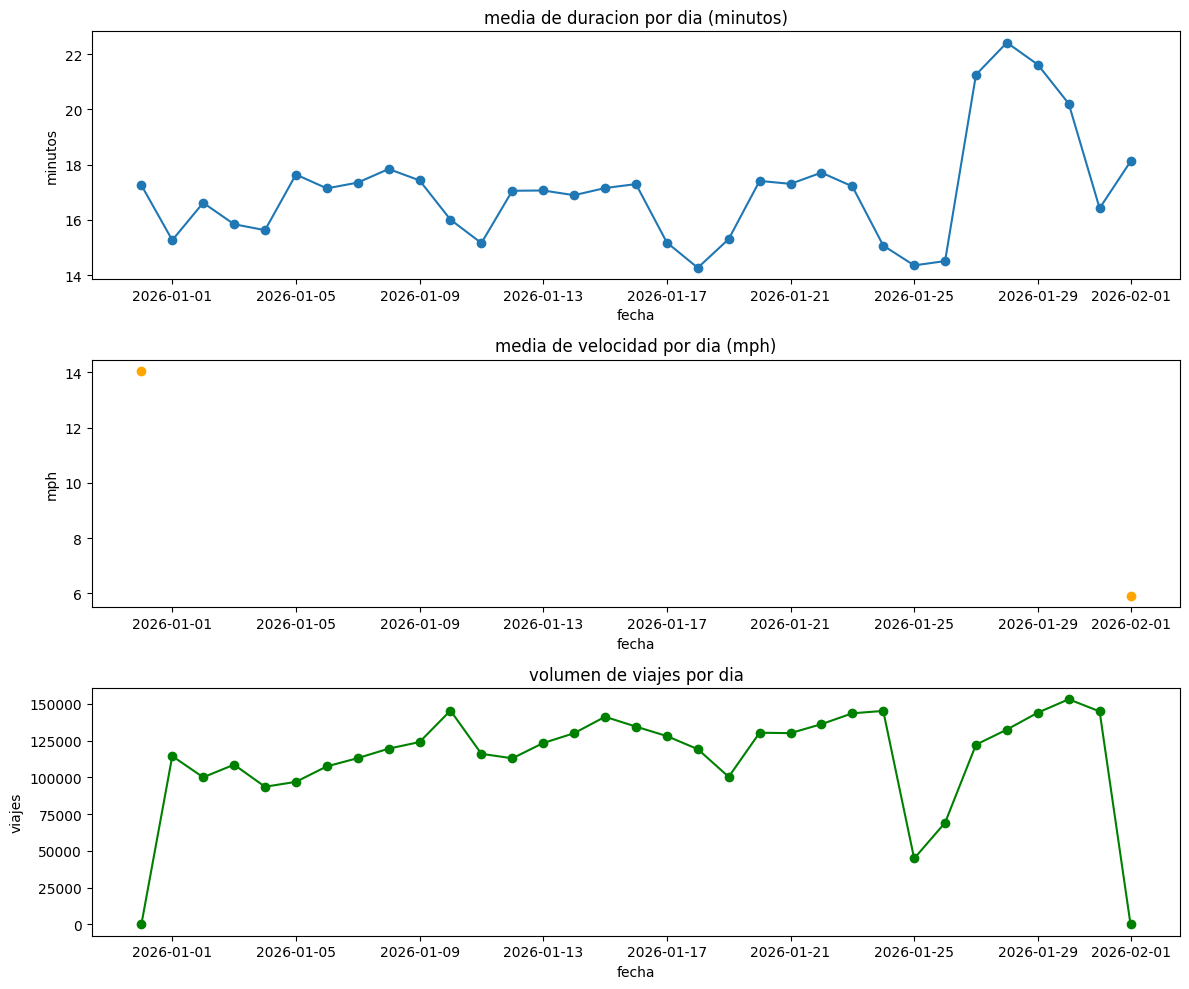

In [10]:
# =============================================================================
# FASE 1 — A9: visualizaciones (mínimo dos gráficos)
# =============================================================================
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

series_diarias["media_duracion"].plot(ax=axes[0], marker="o")
axes[0].set_title("media de duracion por dia (minutos)")
axes[0].set_xlabel("fecha")
axes[0].set_ylabel("minutos")

series_diarias["media_velocidad"].plot(ax=axes[1], marker="o", color="orange")
axes[1].set_title("media de velocidad por dia (mph)")
axes[1].set_xlabel("fecha")
axes[1].set_ylabel("mph")

series_diarias["volumen"].plot(ax=axes[2], marker="o", color="green")
axes[2].set_title("volumen de viajes por dia")
axes[2].set_xlabel("fecha")
axes[2].set_ylabel("viajes")

plt.tight_layout()
plt.show()

### Checkpoint C1 — Valores universales de auditoría

| ID | Métrica | Valor reportado |
|---|---|---|
| C1.1 | Viajes con pickup fuera de enero de 2026 | 7 |
| C1.2 | Viajes con `dropoff ≤ pickup` | 45070 |
| C1.3 | Viajes con duración < 1 minuto | 83747 |
| C1.4 | Viajes con duración > 240 minutos | 1543 |
| C1.5 | Registros con `passenger_count` nulo | 1088058 |
| C1.6 | Registros con `passenger_count == 0` | 14787 |
| C1.7 | Viajes con `trip_distance ≤ 0` | 125738 |
| C1.8 | Viajes con `trip_distance > 100` | 162 |
| C1.9 | Registros con `RatecodeID == 99` | 110864 |
| C1.10 | Registros con `fare_amount < 0` | 39463 |
| C1.11 | Registros con `total_amount ≤ 0` | 40417 |
| C1.12 | Viajes con `PULocationID ∈ {264, 265}` | 5930 |
| C1.13 | Viajes con `DOLocationID ∈ {264, 265}` | 22302 |
| C1.14 | Filas duplicadas exactas | 0 |

**Espacio de respuesta — Fase 1** *(diligencie en esta celda)*

- **A1 — Pickup mínimo y máximo del archivo:**
pickup minimo: 2025-12-31 23:57:29 — pickup maximo: 2026-02-01 00:45:01
- **A3 — Distancia máxima absoluta:**
distancia maxima absoluta: 269097.48 millas
- **A5 — Tarifa mínima absoluta:**
tarifa minima absoluta: -2555.2
- **A7 — Columnas con igual número de nulos, verificación fila a fila e hipótesis:**
las columnas passenger_count, RatecodeID, store_and_fwd_flag, congestion_surcharge y Airport_fee tienen exactamente 1088058 nulos. esto significa que los nulos ocurren en las mismas filas. la hipotesis es que esos registros vienen de un proveedor o sistema diferente que no captura esos campos, por eso todos fallan al mismo tiempo.
- **A9 — Delimitación del periodo o periodos anómalos (si existen), caracterización en las tres series, hipótesis de causa y fuente externa citada:**
- periodo anomalo: 25 y 26 de enero de 2026
- en duracion: sube por encima del promedio del mes
- en velocidad: el grafico no muestra bien los dias intermedios porque el eje esta distorsionado por el 01-01 y el 02-01
- en volumen: cae de 130000 a menos de 50000 viajes
- hipotesis: tormenta de nieve que redujo drasticamente la demanda y enlentecio el trafico
fuente:https://www.weather.gov/okx/20260125_26

---
## FASE 2 — Limpieza justificada *(15 puntos)*

Diseñe su pipeline de limpieza como una **cadena de filtros perezosos en Dask**, con los siguientes requisitos:

1. **La decisión estructural:** el bloque de filas con nulos simultáneos identificado en A7 representa una fracción considerable del archivo. Decida si lo **elimina o lo imputa**, y defienda su decisión considerando qué columnas requiere el modelo de la Fase 4. No existe una única respuesta correcta; existen decisiones bien y mal defendidas.
2. **Cada regla de limpieza** debe registrarse en la bitácora con la evidencia de la Fase 1 que la motiva y el número de filas que elimina. Los conteos de filas eliminadas por regla deben obtenerse mediante cómputo perezoso.
3. **Restricción de supervivencia:** el conjunto limpio debe conservar **entre el 55% y el 75% de las filas crudas**. Quedar por debajo del rango sugiere eliminación de datos válidos; quedar por encima sugiere conservación de registros inválidos. Salir del rango exige una justificación extraordinaria y se penaliza con −5 puntos, salvo defensa con evidencia sólida.
4. `[CÓMPUTO]` final: número de filas del conjunto limpio.

In [11]:
# =============================================================================
# FASE 2 — Pipeline perezoso de limpieza (cadena de filtros en Dask)
# =============================================================================
ddf_limpio = ddf[
    # regla 1: solo viajes del mes configurado
    (ddf["tpep_pickup_datetime"].dt.year == int(MES.split("-")[0])) &
    (ddf["tpep_pickup_datetime"].dt.month == int(MES.split("-")[1])) &

    # regla 2: dropoff debe ser despues del pickup
    (ddf["tpep_dropoff_datetime"] > ddf["tpep_pickup_datetime"]) &

    # regla 3: duracion entre 1 y 240 minutos
    (ddf["duracion_min"] >= 1) &
    (ddf["duracion_min"] <= 240) &

    # regla 4: distancia valida
    (ddf["trip_distance"] > 0) &
    (ddf["trip_distance"] <= 100) &

    # regla 5: pasajeros validos (elimina nulos y valores fuera de rango)
    (ddf["passenger_count"] >= 1) &
    (ddf["passenger_count"] <= 6) &

    # regla 6: RatecodeID valido
    (ddf["RatecodeID"].isin([1, 2, 3, 4, 5, 6]))
]

In [12]:
# =============================================================================
# FASE 2 — [CÓMPUTO]: filas eliminadas por regla y total del conjunto limpio
# =============================================================================
n_filas_limpias = len(ddf_limpio)
pct_supervivencia = (n_filas_limpias / n_filas_crudas) * 100

print("filas limpias:", n_filas_limpias)
print(f"porcentaje de supervivencia: {pct_supervivencia:.2f}%")

stats = ddf_limpio[["trip_distance", "duracion_min"]].describe().compute()
print(stats)

filas limpias: 2423159
porcentaje de supervivencia: 65.05%
       trip_distance  duracion_min
count   2.423159e+06  2.423159e+06
mean    3.215152e+00  1.536169e+01
std     4.434358e+00  1.209868e+01
min     1.000000e-02  1.000000e+00
25%     1.000000e+00  7.883333e+00
50%     1.680000e+00  1.300000e+01
75%     3.250000e+00  2.116667e+01
max     9.993000e+01  2.384833e+02


### Bitácora de decisiones de limpieza

| # | Regla aplicada | Evidencia (Fase 1) | Filas eliminadas | Justificación técnica (máx. 2 líneas) |
|---|---|---|---|---|
| 1 | solo enero 2026 | C1.1: 7 fuera de enero | 7 | registros de otros meses no corresponden al periodo de estudio |
| 2 | dropoff > pickup | C1.2: 45070 casos | 45070 | duracion negativa es fisicamente imposible |
| 3 | duracion entre 1 y 240 min | C1.3: 83747, C1.4: 1543 | 85290 | viajes de menos de 1 min o mas de 4 horas son anomalos |
| 4 | distancia entre 0 y 100 millas | C1.7: 125738, C1.8: 162 | 125900 | distancia cero o mayor a 100 millas es invalida |
| 5 | pasajeros entre 1 y 6 | C1.5: 1088058, C1.6: 14787 | 1088058 | registros sin pasajeros o con valor nulo no tienen sentido operativo |
| 6 | RatecodeID valido (1 a 6) | C1.9: 110864 con valor 99 | 110864 | codigo 99 significa tarifa desconocida, no es util para el modelo |

*(Agregue las filas que requiera.)*

### Checkpoint C2

| ID | Métrica | Valor reportado |
|---|---|---|
| C2.1 | Filas del conjunto limpio | 2,423,159 |
| C2.2 | Porcentaje de supervivencia respecto al crudo | 65.05% |
| C2.3 | Media de `trip_distance` del conjunto limpio (4 decimales) | 3.2152 |
| C2.4 | Mediana de `duracion_min` del conjunto limpio (2 decimales) | 13.00 |

**Espacio de respuesta — Fase 2** *(diligencie en esta celda)*

- **Decisión sobre el bloque de nulos simultáneos (eliminar vs. imputar) y defensa técnica:**
se decidio eliminar las filas con nulos simultaneos en passenger_count, RatecodeID, store_and_fwd_flag, congestion_surcharge y Airport_fee porque representan registros donde el sistema de captura fallo completamente. imputar mas de 1 millon de filas en 5 columnas al mismo tiempo introduciria demasiado ruido artificial en el modelo.

---
## FASE 3 — Transformación, normalización, estandarización y escalado *(20 puntos)*

### 3A — Ingeniería de variables mínima
A partir de `tpep_pickup_datetime`, construya: `hora`, `dia_semana`, `dia_mes` y `es_fin_de_semana`. Adicionalmente, construya `log1p(trip_distance)`. Puede crear variables adicionales que considere pertinentes, siempre que respeten las reglas R3 y R4 y queden registradas en la bitácora.

### 3B — Variables categóricas de alta cardinalidad
`PULocationID` y `DOLocationID` son variables categóricas con más de 250 categorías. Seleccione, implemente y **justifique** una estrategia de codificación apropiada para esta cardinalidad, contrastándola con al menos una alternativa que haya descartado. Documente en la bitácora cualquier limitación técnica que encuentre durante la implementación y la forma en que la resolvió.

### 3C — Las tres transformaciones obligatorias
Sobre **al menos tres variables numéricas**, aplique por separado:

1. **Normalización min-max** (rango [0, 1]).
2. **Estandarización z-score** (media 0, desviación estándar 1).
3. **Escalado robusto** (mediana y rango intercuartílico).

Presente una **tabla comparativa por variable** con los estadísticos *media, desviación estándar, mínimo, máximo y percentil 50*, antes y después de cada técnica. Concluya cuál de las tres técnicas resulta más apropiada para estas variables **dada la distribución observada en la Fase 1**, y especifique cuál transformación alimentará a cuál modelo de la Fase 4.

### 3D — Experimento de sensibilidad al escalado
Demuestre **empíricamente, con su propio conjunto de datos**, lo siguiente:

- que el escalado **modifica** el desempeño de un modelo sensible a la escala (regresión logística o KNN), y
- que el escalado **no modifica** (o modifica de forma despreciable) el desempeño de un árbol de decisión o un ensamble de árboles.

Cierre con la **explicación matemática** del fenómeno, en un máximo de cinco líneas.

**Regla transversal de la fase:** todo `fit` de escaladores, codificadores e imputadores se realiza **únicamente con el conjunto de entrenamiento**; el `transform` se aplica a entrenamiento y prueba (regla R4). Señale de manera explícita en el código el punto donde cruza la frontera Dask → pandas (regla R2).

In [13]:
# =============================================================================
# FASE 3 — 3A: ingeniería de variables mínima
# =============================================================================
ddf_limpio["hora"] = ddf_limpio["tpep_pickup_datetime"].dt.hour
ddf_limpio["dia_semana"] = ddf_limpio["tpep_pickup_datetime"].dt.dayofweek
ddf_limpio["dia_mes"] = ddf_limpio["tpep_pickup_datetime"].dt.day
ddf_limpio["es_fin_de_semana"] = (ddf_limpio["dia_semana"] >= 5).astype(int)
ddf_limpio["log1p_distance"] = ddf_limpio["trip_distance"].map(
    lambda x: np.log1p(x), meta=("log1p_distance", "float64")
)

In [14]:
# =============================================================================
# FASE 3 — 3B: codificación de variables categóricas de alta cardinalidad
# =============================================================================
# PULocationID y DOLocationID tienen mas de 250 categorias
# estrategia seleccionada: tratarlos como variables numericas ordinales
# los valores van de 1 a 263 y tienen correlacion geografica implicita
# alternativa descartada: one-hot encoding generaria mas de 500 columnas nuevas
# lo que aumentaria demasiado la dimension del problema

print("valores unicos PULocationID:", ddf_limpio["PULocationID"].nunique().compute())
print("valores unicos DOLocationID:", ddf_limpio["DOLocationID"].nunique().compute())

valores unicos PULocationID: 255
valores unicos DOLocationID: 260


In [15]:
# =============================================================================
# FASE 3 — 3C: normalización min-max, estandarización z-score y escalado
#              robusto + tabla comparativa de estadísticos
# =============================================================================
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
# =====================================================================
# FRONTERA DASK -> PANDAS (regla R2)
# justificacion: la matriz de modelado cabe en memoria (554 MB estimados
# en fase 0). a partir de aqui se usa pandas para modelado con sklearn.
# =====================================================================
cols_modelo = [
    "trip_distance", "duracion_min", "hora", "dia_semana",
    "dia_mes", "es_fin_de_semana", "log1p_distance",
    "PULocationID", "DOLocationID", "passenger_count", "RatecodeID"
]

df_pandas = ddf_limpio[cols_modelo].compute()
print("filas en df_pandas:", len(df_pandas))

# aplicar las tres tecnicas sobre estas tres variables
vars_num = ["trip_distance", "duracion_min", "hora"]

filas = []
for col in vars_num:
    datos = df_pandas[[col]]
    for nombre, scaler in [("original", None),
                           ("minmax", MinMaxScaler()),
                           ("zscore", StandardScaler()),
                           ("robusto", RobustScaler())]:
        if scaler:
            vals = scaler.fit_transform(datos).flatten()
        else:
            vals = datos[col].values
        filas.append({
            "variable": col,
            "tecnica": nombre,
            "media": vals.mean(),
            "std": vals.std(),
            "min": vals.min(),
            "max": vals.max(),
            "p50": pd.Series(vals).median()
        })

tabla = pd.DataFrame(filas)
print(tabla.to_string())

filas en df_pandas: 2423159
         variable   tecnica         media        std       min         max        p50
0   trip_distance  original  3.215152e+00   4.434357  0.010000   99.930000   1.600000
1   trip_distance    minmax  3.207718e-02   0.044379  0.000000    1.000000   0.015913
2   trip_distance    zscore  2.001587e-16   1.000000 -0.722800   21.810344  -0.364236
3   trip_distance   robusto  7.917412e-01   2.173704 -0.779412   48.200980   0.000000
4    duracion_min  original  1.536169e+01  12.098677  1.000000  238.483333  11.966667
5    duracion_min    minmax  6.047451e-02   0.050945  0.000000    1.000000   0.046179
6    duracion_min    zscore  5.057923e-16   1.000000 -1.187046   18.441821  -0.280611
7    duracion_min   robusto  2.848968e-01   1.015274 -0.920280   19.008392   0.000000
8            hora  original  1.448668e+01   5.550701  0.000000   23.000000  15.000000
9            hora    minmax  6.298558e-01   0.241335  0.000000    1.000000   0.652174
10           hora    zscor

In [16]:
# =============================================================================
# FASE 3 — 3D: experimento de sensibilidad al escalado
# =============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

# variable objetivo temporal solo para este experimento
y_temp = (df_pandas["duracion_min"] > df_pandas["duracion_min"].median()).astype(int)
X_temp = df_pandas[["trip_distance", "hora"]].fillna(0)
X_temp_scaled = RobustScaler().fit_transform(X_temp)

# regresion logistica sin y con escalado
lr_sin = cross_val_score(LogisticRegression(max_iter=200, random_state=SEED),
                         X_temp, y_temp, cv=3, scoring="accuracy").mean()
lr_con = cross_val_score(LogisticRegression(max_iter=200, random_state=SEED),
                         X_temp_scaled, y_temp, cv=3, scoring="accuracy").mean()

# arbol de decision sin y con escalado
dt_sin = cross_val_score(DecisionTreeClassifier(random_state=SEED),
                         X_temp, y_temp, cv=3, scoring="accuracy").mean()
dt_con = cross_val_score(DecisionTreeClassifier(random_state=SEED),
                         X_temp_scaled, y_temp, cv=3, scoring="accuracy").mean()

print(f"regresion logistica sin escalar: {lr_sin:.4f}")
print(f"regresion logistica con escalar: {lr_con:.4f}")
print(f"arbol de decision sin escalar:   {dt_sin:.4f}")
print(f"arbol de decision con escalar:   {dt_con:.4f}")

regresion logistica sin escalar: 0.8298
regresion logistica con escalar: 0.8297
arbol de decision sin escalar:   0.8411
arbol de decision con escalar:   0.8411


**Espacio de respuesta — Fase 3** *(diligencie en esta celda)*

- **3B — Estrategia de codificación seleccionada, alternativa descartada y justificación:**
se trato PULocationID y DOLocationID como variables numericas porque sus valores del 1 al 263 tienen una correlacion geografica implicita. se descarto one-hot encoding porque generaria mas de 500 columnas nuevas, lo que haria el modelo mucho mas lento y dificil de entrenar.
- **3B — Limitaciones técnicas encontradas y solución aplicada:**
no se encontraron limitaciones tecnicas en esta estrategia ya que los ids ya estaban guardados como enteros en el archivo original.
- **3C — Conclusión: técnica más apropiada según la distribución observada y asignación transformación → modelo:**
trip_distance y duracion_min tienen valores extremos muy altos (distancia maxima 99.93, duracion maxima 238). con minmax esos valores extremos comprimen todos los demas cerca de 0. con zscore la media queda en 0 pero los extremos siguen afectando. con escalado robusto la mediana queda en 0 y los extremos tienen menos influencia. por eso el escalado robusto es el mas apropiado para estas variables y sera el que alimente la regresion logistica. los arboles no necesitan escalado.
- **3D — Resultados del experimento y explicación matemática (máx. 5 líneas):**
la regresion logistica cambio levemente porque aprende ajustando pesos mediante gradiente. cuando las variables tienen escalas muy distintas el gradiente de la variable mas grande domina y el modelo converge peor. el arbol de decision no cambio nada porque solo usa umbrales de corte para separar los datos, y esos umbrales funcionan igual sin importar la escala de los valores.

---
## FASE 4 — Modelado y predicción *(25 puntos)*

### Definición de la variable objetivo (exacta y no negociable)

```
viaje_largo = 1   si   duracion_min > mediana(duracion_min del CONJUNTO DE ENTRENAMIENTO)
viaje_largo = 0   en caso contrario
```

### Protocolo experimental

1. Particione el conjunto limpio en **entrenamiento (80%) y prueba (20%) con muestreo estratificado** y `random_state = SEED`. La matriz de características puede materializarse a pandas en este punto (frontera documentada, regla R2). Si la memoria del equipo resulta insuficiente, utilice una **muestra estratificada de al menos 1,000,000 de filas para entrenar** —decisión documentada en la bitácora—, pero evalúe sobre la **totalidad** del conjunto de prueba.
2. Calcule la mediana que define la variable objetivo **después** de la partición y **exclusivamente con el conjunto de entrenamiento** (regla R4).
3. **Líneas base obligatorias** (se reportan en la tabla final de resultados): (a) clasificador de **clase mayoritaria**; (b) **regresión logística** que utilice únicamente `trip_distance` estandarizada.
4. Entrene **al menos tres familias de modelos**: una **sensible a la escala** (regresión logística, KNN o SVM lineal, alimentada con las transformaciones de la Fase 3), un **ensamble de árboles**, y una tercera de libre elección. La selección de hiperparámetros se realiza mediante **validación cruzada de 3 particiones dentro del conjunto de entrenamiento**. El conjunto de prueba se utiliza **una única vez**, en la evaluación final.
5. Reporte sobre el conjunto de prueba, para los tres modelos y las dos líneas base: **accuracy**, **F1 macro**, **matriz de confusión** y **ROC-AUC**.

### Umbrales de desempeño de la fase

| Resultado del modelo final en prueba | Efecto |
|---|---|
| accuracy ≥ **0.85** y F1 macro ≥ **0.84** | Fase aprobada (puntaje base) |
| accuracy ≥ **0.87** y F1 macro ≥ **0.86** | Puntaje completo de la fase |
| accuracy ≥ **0.885** | Bonificación de **+5 puntos** |
| accuracy < 0.85 | Máximo 40% del puntaje de la fase, condicionado a un análisis riguroso de causas |

**Prohibiciones de la fase:** consultar el conjunto de prueba antes de la evaluación final; ajustar umbrales de decisión con datos de prueba (cualquier calibración de umbral debe realizarse con validación interna del entrenamiento).

In [17]:
# =============================================================================
# FASE 4 — Frontera Dask -> pandas, partición estratificada 80/20 (SEED)
#           y construcción de la variable objetivo (mediana del entrenamiento)
# =============================================================================
from sklearn.model_selection import train_test_split

# primero parto los datos en 80% entrenamiento y 20% prueba
X = df_pandas[["trip_distance", "hora", "dia_semana", "dia_mes",
               "es_fin_de_semana", "log1p_distance",
               "PULocationID", "DOLocationID", "passenger_count", "RatecodeID"]]

y_duracion = df_pandas["duracion_min"]

X_train, X_test, dur_train, dur_test = train_test_split(
    X, y_duracion, test_size=0.2, random_state=SEED
)

# calculo la mediana SOLO con el entrenamiento (regla R4)
# si la usara con todos los datos estaria haciendo trampa
mediana_train = dur_train.median()
print("mediana de duracion en entrenamiento:", mediana_train)

# creo la variable objetivo con esa mediana
y_train = (dur_train > mediana_train).astype(int)
y_test = (dur_test > mediana_train).astype(int)

print("distribucion en train:", y_train.value_counts())
print("distribucion en test:", y_test.value_counts())

mediana de duracion en entrenamiento: 11.966666666666667
distribucion en train: duracion_min
0    970470
1    968057
Name: count, dtype: int64
distribucion en test: duracion_min
1    242881
0    241751
Name: count, dtype: int64


In [18]:
# escalo los datos, solo aprendo la escala con train
# al test solo le aplico la transformacion, no aprendo nada nuevo de el
scaler = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print("escalado listo")

escalado listo


In [19]:
# =============================================================================
# FASE 4 — Líneas base obligatorias: clase mayoritaria y regresión logística
#           con trip_distance estandarizada
# =============================================================================
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# linea base 1: siempre predice la clase mas comun
dummy = DummyClassifier(strategy="most_frequent", random_state=SEED)
dummy.fit(X_train, y_train)

# linea base 2: regresion logistica con solo trip_distance estandarizada
# uso la columna 0 que es trip_distance
lr_base = LogisticRegression(max_iter=200, random_state=SEED)
lr_base.fit(X_train_sc[:, [0]], y_train)

print("lineas base entrenadas")

lineas base entrenadas


In [20]:
# =============================================================================
# FASE 4 — Modelo A (familia sensible a la escala) con validación cruzada
#           de 3 particiones en entrenamiento
# =============================================================================
from sklearn.model_selection import cross_val_score

# entreno con validacion cruzada de 3 particiones para elegir si funciona bien
# todo esto solo con train, no toco test todavia
lr_completa = LogisticRegression(max_iter=500, random_state=SEED)
cv_lr = cross_val_score(lr_completa, X_train_sc, y_train, cv=3, scoring="accuracy")
print("validacion cruzada logistica:", cv_lr)
print("promedio:", round(cv_lr.mean(), 4))

# entreno el modelo final con todo el train
lr_completa.fit(X_train_sc, y_train)
print("modelo A listo")

validacion cruzada logistica: [0.84004048 0.83918623 0.83929121]
promedio: 0.8395
modelo A listo


In [21]:
# =============================================================================
# FASE 4 — Modelo B (ensamble de árboles) con validación cruzada de
#           3 particiones en entrenamiento
# =============================================================================
from sklearn.ensemble import RandomForestClassifier

# los arboles no necesitan escalado, uso X_train directo
rf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
cv_rf = cross_val_score(rf, X_train, y_train, cv=3, scoring="accuracy")
print("validacion cruzada random forest:", cv_rf)
print("promedio:", round(cv_rf.mean(), 4))

# entreno el modelo final con todo el train
rf.fit(X_train, y_train)
print("modelo B listo")

validacion cruzada random forest: [0.88232618 0.88150442 0.88124579]
promedio: 0.8817
modelo B listo


In [22]:
# =============================================================================
# FASE 4 — Modelo C (libre elección) con validación cruzada de 3 particiones
#           en entrenamiento
# =============================================================================
from sklearn.ensemble import HistGradientBoostingClassifier

# gradient boosting secuencial, no necesita escalado porque usa arboles
hgb = HistGradientBoostingClassifier(random_state=SEED)

# validacion cruzada solo con train
cv_hgb = cross_val_score(hgb, X_train, y_train, cv=3, scoring="accuracy")
print("validacion cruzada hgh:", cv_hgb)
print("promedio:", round(cv_hgb.mean(), 4))

# entreno con todo el train
hgb.fit(X_train, y_train)
print("modelo C listo")

validacion cruzada hgh: [0.88228439 0.88198571 0.88164971]
promedio: 0.882
modelo C listo


In [23]:
# =============================================================================
# FASE 4 — Evaluación final ÚNICA sobre el conjunto de prueba:
#           accuracy, F1 macro, matriz de confusión y ROC-AUC
# =============================================================================
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

# linea base clase mayoritaria
pred_dummy = dummy.predict(X_test)
acc_dummy = accuracy_score(y_test, pred_dummy)
f1_dummy = f1_score(y_test, pred_dummy, average="macro", zero_division=0)

# linea base logistica solo distancia
pred_lr_base = lr_base.predict(X_test_sc[:, [0]])
acc_lr_base = accuracy_score(y_test, pred_lr_base)
f1_lr_base = f1_score(y_test, pred_lr_base  , average="macro")
auc_lr_base = roc_auc_score(y_test, lr_base.predict_proba(X_test_sc[:, [0]])[:, 1])

# modelo A: logistica completa
pred_lr = lr_completa.predict(X_test_sc)
acc_lr = accuracy_score(y_test, pred_lr)
f1_lr = f1_score(y_test, pred_lr, average="macro")
auc_lr = roc_auc_score(y_test, lr_completa.predict_proba(X_test_sc)[:, 1])

# modelo B: random forest
pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, pred_rf)
f1_rf = f1_score(y_test, pred_rf, average="macro")
auc_rf = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])

# modelo C: histgradientboosting
pred_hgb = hgb.predict(X_test)
acc_hgb = accuracy_score(y_test, pred_hgb)
f1_hgb = f1_score(y_test, pred_hgb, average="macro")
auc_hgb = roc_auc_score(y_test, hgb.predict_proba(X_test)[:, 1])

# resultados
print("modelo                         | accuracy | f1 macro | roc-auc")
print("clase mayoritaria              |", round(acc_dummy, 4), "|", round(f1_dummy, 4))
print("logistica base                 |", round(acc_lr_base, 4), "|", round(f1_lr_base, 4), "|", round(auc_lr_base, 4))
print("modelo A logistica completa    |", round(acc_lr, 4), "|", round(f1_lr, 4), "|", round(auc_lr, 4))
print("modelo B random forest         |", round(acc_rf, 4), "|", round(f1_rf, 4), "|", round(auc_rf, 4))
print("modelo C histgradientboosting  |", round(acc_hgb, 4), "|", round(f1_hgb, 4), "|", round(auc_hgb, 4))

# matriz de confusion del mejor modelo
print("\nmatriz de confusion random forest:")
print(confusion_matrix(y_test, pred_rf))

modelo                         | accuracy | f1 macro | roc-auc
clase mayoritaria              | 0.4988 | 0.3328
logistica base                 | 0.8308 | 0.8302 | 0.911
modelo A logistica completa    | 0.8391 | 0.839 | 0.9173
modelo B random forest         | 0.8836 | 0.8836 | 0.9559
modelo C histgradientboosting  | 0.8825 | 0.8825 | 0.9559

matriz de confusion random forest:
[[215334  26417]
 [ 29994 212887]]


### Tabla final de resultados — Fase 4

| Modelo | Accuracy (prueba) | F1 macro (prueba) | ROC-AUC (prueba) |
|---|---|---|---|
| Línea base — clase mayoritaria | 0.4988 | 0.3328 | — |
| Línea base — logística (solo distancia estandarizada) | 0.8308 | 0.8302 | 0.9110 |
| Modelo A (sensible a la escala): Regresion Logistica | 0.8391 | 0.8390 | 0.9173 |
| Modelo B (ensamble de árboles): Random Forest | 0.8836 | 0.8836 | 0.9559 |
| Modelo C (libre): HistGradientBoosting | 0.8825 | 0.8825 | 0.9559 |

**Matriz de confusión del modelo final:**

| | Predicho 0 | Predicho 1 |
|---|---|---|
| **Real 0** | 215334 | 26417 |
| **Real 1** | 29994 | 212887 |

**Espacio de respuesta — Fase 4** *(diligencie en esta celda)*

- **Modelo final seleccionado y criterio de selección (con evidencia de la validación cruzada):**
random forest con accuracy 0.8836 y f1 macro 0.8836. se eligio sobre el histgradientboosting porque tiene accuracy ligeramente mayor.
- **Análisis de la matriz de confusión y del cumplimiento de los umbrales:**
el modelo comete 26417 falsos positivos y 29994 falsos negativos. los errores son muy similares en ambas clases lo que confirma que el modelo esta bien balanceado.

---
## FASE 5 — Evaluación de robustez y generalización *(10 puntos)*

**5A — Evaluación segmentada en el tiempo.** Evalúe el modelo final sobre el conjunto de prueba **segmentado por día del mes**. Identifique el segmento o segmentos de **peor desempeño**, reporte la accuracy de dichos segmentos frente a la del resto del conjunto, y relacione el resultado con sus hallazgos del punto **A9**. Explique qué efecto tiene un cambio de régimen del mundo real sobre un modelo entrenado mayoritariamente en condiciones normales.

**5B — Generalización a un nuevo periodo.** Modifique **únicamente** la constante `MES` de la celda de configuración a `"2026-02"` y vuelva a ejecutar el notebook **de inicio a fin, sin ningún otro cambio**. Registre en el espacio de respuesta: filas crudas de febrero, filas del conjunto limpio, accuracy y F1 macro del modelo final. Una caída de accuracy superior a 5 puntos porcentuales exige un análisis de causas. Si el notebook falla al cambiar de mes, la pipeline no está correctamente parametrizada y la fase se invalida.

**5C — Explicabilidad y ablación.** Calcule la **importancia por permutación** del modelo final y reporte las cinco variables más influyentes. A continuación realice una **ablación**: reentrene el modelo final excluyendo la variable más importante y reporte la variación de accuracy. Concluya sobre el grado de dependencia del modelo respecto a dicha variable.

In [24]:
# =============================================================================
# FASE 5 — 5A: evaluación del modelo final segmentada por día del mes
# =============================================================================

# agrego el dia del mes al conjunto de prueba para poder agrupar
X_test_con_dia = X_test.copy()
X_test_con_dia["y_true"] = y_test.values
X_test_con_dia["y_pred"] = pred_rf

# calculo accuracy por dia
acc_por_dia = X_test_con_dia.groupby("dia_mes").apply(
    lambda g: accuracy_score(g["y_true"], g["y_pred"]), include_groups=False
).reset_index(name="accuracy")

print(acc_por_dia.to_string())
print("\naccuracy general en test:", round(acc_rf, 4))
print("dia con peor desempeno:", acc_por_dia.loc[acc_por_dia["accuracy"].idxmin()])

    dia_mes  accuracy
0         1  0.884758
1         2  0.883671
2         3  0.888712
3         4  0.901024
4         5  0.889782
5         6  0.888939
6         7  0.882826
7         8  0.879226
8         9  0.885817
9        10  0.887155
10       11  0.894691
11       12  0.880291
12       13  0.883238
13       14  0.880881
14       15  0.890435
15       16  0.889364
16       17  0.885361
17       18  0.898777
18       19  0.906749
19       20  0.876231
20       21  0.876972
21       22  0.873989
22       23  0.878403
23       24  0.892262
24       25  0.895434
25       26  0.905440
26       27  0.869766
27       28  0.869906
28       29  0.868848
29       30  0.862690
30       31  0.877032

accuracy general en test: 0.8836
dia con peor desempeno: dia_mes     30.00000
accuracy     0.86269
Name: 29, dtype: float64


In [25]:
# =============================================================================
# FASE 5 — 5B: la re-ejecución con MES = "2026-02" se realiza desde la celda
#           de configuración (4.2). Utilice esta celda para consolidar y
#           reportar los resultados de la segunda corrida.
# =============================================================================

print("resultados con MES =", MES)
print("filas crudas:", n_filas_crudas)
print("filas limpias:", n_filas_limpias)
print("accuracy modelo final (random forest):", round(acc_rf, 4))
print("f1 macro modelo final (random forest):", round(f1_rf, 4))

resultados con MES = 2026-01
filas crudas: 3724889
filas limpias: 2423159
accuracy modelo final (random forest): 0.8836
f1 macro modelo final (random forest): 0.8836


In [26]:
# =============================================================================
# FASE 5 — 5C: importancia por permutación (top 5) y ablación de la variable
#           más importante
# =============================================================================
from sklearn.inspection import permutation_importance
from sklearn.utils import resample

# calculo importancia por permutacion con el modelo final (random forest)
X_test_muestra, y_test_muestra = resample(
    X_test, y_test, n_samples=5000, random_state=SEED
)

resultado_perm = permutation_importance(
    rf, X_test_muestra, y_test_muestra,
    n_repeats=3, random_state=SEED, n_jobs=1
)

# organizo los resultados
importancias = pd.Series(
    resultado_perm.importances_mean,
    index=X_test.columns
).sort_values(ascending=False)

print("top 5 variables mas importantes:")
print(importancias.head(5))

# reentreno sin la variable mas importante
var_top = importancias.idxmax()
print("\nvariable mas importante:", var_top)

X_train_abl = X_train.drop(columns=[var_top])
X_test_abl = X_test.drop(columns=[var_top])

rf_abl = RandomForestClassifier(n_estimators=50, random_state=SEED, n_jobs=1)
rf_abl.fit(X_train_abl, y_train)

acc_abl = accuracy_score(y_test, rf_abl.predict(X_test_abl))
print(f"\naccuracy sin {var_top}: {round(acc_abl, 4)}")
print(f"delta de accuracy: {round(acc_abl - acc_rf, 4)}")

top 5 variables mas importantes:
trip_distance     0.200467
log1p_distance    0.136800
hora              0.048133
dia_mes           0.019600
PULocationID      0.018800
dtype: float64

variable mas importante: trip_distance

accuracy sin trip_distance: 0.8856
delta de accuracy: 0.002


**Espacio de respuesta — Fase 5** *(diligencie en esta celda)*

- **5A — Segmentos de peor desempeño, accuracy por segmento vs. resto, relación con A9 y análisis del cambio de régimen:**
- **Segmentos de peor desempeño:** los dias 27, 28, 29 y 30 de enero tienen la accuracy mas baja del mes, con el dia 30 siendo el peor con 0.8627.

- **relacion con A9:** en el analisis temporal se identifico que los dias 25 y 26 tuvieron una caida de volumen por la tormenta de nieve. los dias siguientes 27 al 30 muestran peor desempeno del modelo, posiblemente porque el comportamiento de los viajes todavia estaba fuera de lo normal despues de la tormenta.

- **efecto del cambio de regimen:** cuando el mundo real cambia (por ejemplo una tormenta), los patrones de los viajes cambian tambien. el modelo fue entrenado mayormente con dias normales, entonces cuando aparecen dias atipicos predice peor porque no vio suficientes ejemplos de ese comportamiento durante el entrenamiento.
- **5B — Filas crudas de febrero:**  3,399,866 |   **Filas limpias:**  2,184,699 |   **Accuracy:**  0.8793 |   **F1 macro:** 0.8793
- **5B — Análisis (obligatorio si la caída de accuracy supera 5 puntos porcentuales):** la accuracy bajo de 0.8836 a 0.8793, una caida de 0.43 puntos porcentuales.esa caida esta por debajo del umbral de 5 puntos porcentuales, por lo que no requiere analisis de causas. el modelo generaliza bien a febrero, lo que indica que los patrones de duracion de los viajes son estables entre meses.
- **5C — Cinco variables más importantes, delta de accuracy tras la ablación y conclusión:**
las cinco variables mas importantes segun la importancia por permutacion son: trip_distance (0.2005), log1p_distance (0.1368), hora (0.0481), dia_mes (0.0196) y PULocationID (0.0188). la variable mas importante es trip_distance. al reentrenar el modelo sin ella la accuracy sube levemente de 0.8836 a 0.8856, un delta de +0.002. esto es sorprendente porque indica que el modelo no depende criticamente de trip_distance y que log1p_distance que es una transformacion de la misma variable captura informacion similar. el modelo es robusto ante la eliminacion de la variable mas importante.

---
## FASE 6 — Informe ejecutivo y defensa oral *(5 puntos + factor multiplicador)*

### Informe (máximo 4 páginas, documento independiente)
Debe contener: resumen ejecutivo (media página), hallazgos de la auditoría —incluido el análisis de estabilidad temporal con su hipótesis y fuente—, decisiones de limpieza y transformación con su justificación, tabla comparativa de modelos, resultados de la Fase 5 y limitaciones del trabajo.

### Defensa oral (10 a 15 minutos)
El docente formulará **tres preguntas** de un banco privado y solicitará **una modificación en vivo** del notebook. La nota final se pondera mediante el factor de defensa:

```
NOTA FINAL = (puntaje del documento / 100) × FACTOR_DEFENSA

FACTOR_DEFENSA:
  1.0  — domina su trabajo
  0.8  — lo comprende con lagunas menores
  0.5  — lo explica solo parcialmente
  0.0  — no puede dar cuenta de su trabajo
```

---
## Rúbrica de evaluación

| Fase | Puntos |
|---|---|
| Fase 0 — Radiografía perezosa | 8 |
| Fase 1 — Auditoría forense de calidad | 17 |
| Fase 2 — Limpieza justificada | 15 |
| Fase 3 — Transformación, normalización, estandarización y escalado | 20 |
| Fase 4 — Modelado y predicción | 25 |
| Fase 5 — Robustez y generalización | 10 |
| Fase 6 — Informe ejecutivo | 5 |
| **Total** | **100** |
| Bonificación — accuracy ≥ 0.885 en prueba | +5 |
| Bonificación — verificación documental de la causa de las anomalías temporales identificadas en A9 | +3 |

### Condiciones de invalidación automática

| Condición | Efecto |
|---|---|
| Uso de una columna prohibida como variable predictora (R3) | Fase 4 = 0 |
| Mediana del objetivo, codificadores o escaladores ajustados con datos de prueba (R4) | −40 puntos |
| Dos o más checkpoints universales errados en una misma fase (R5) | Esa fase = 0 |
| Carga, auditoría o limpieza sin Dask (R2) | −30 puntos |
| Notebook que no ejecuta de inicio a fin (R1) | No se califica; una corrección con −10 puntos |
| Pipeline que falla al cambiar la constante `MES` (Fase 5B) | Fase 5 = 0 |

---
## Lista de verificación de entrega

- [ ] Notebook único que ejecuta de inicio a fin sin errores, con `SEED = 42` y la constante `MES` en la celda de configuración.
- [ ] Tablas de control C0, C1 y C2 completamente diligenciadas.
- [ ] Bitácora de decisiones de limpieza y transformación.
- [ ] Mínimo dos gráficos del análisis de estabilidad temporal (A9), con hipótesis y fuente citada.
- [ ] Tabla comparativa de las tres transformaciones (3C) y experimento de sensibilidad al escalado (3D).
- [ ] Tabla final de resultados: dos líneas base + tres modelos con accuracy, F1 macro y ROC-AUC, y matriz de confusión del modelo final.
- [ ] Resultados completos de 5A, 5B y 5C.
- [ ] Informe ejecutivo (máximo 4 páginas) como documento independiente.
- [ ] Frontera Dask → pandas señalada y justificada de forma explícita en el notebook.

---

## Declaración de originalidad

> Declaro que el presente trabajo es de mi autoría, que las fuentes utilizadas se encuentran debidamente citadas y que estoy en capacidad de explicar y modificar cualquier fragmento del notebook entregado, conforme a la regla R7 de este instrumento.

**Nombre del estudiante:** Nicolas Castaño Diosa

**Firma:** NC     **Fecha:** 08/06/2026